CSV file created successfully.

Training Gradient Descent model...
------------------------------
Slope (m): 171.8685
Intercept (b): 2.4776
Prediction for 2500 sqft: $429673.85
------------------------------


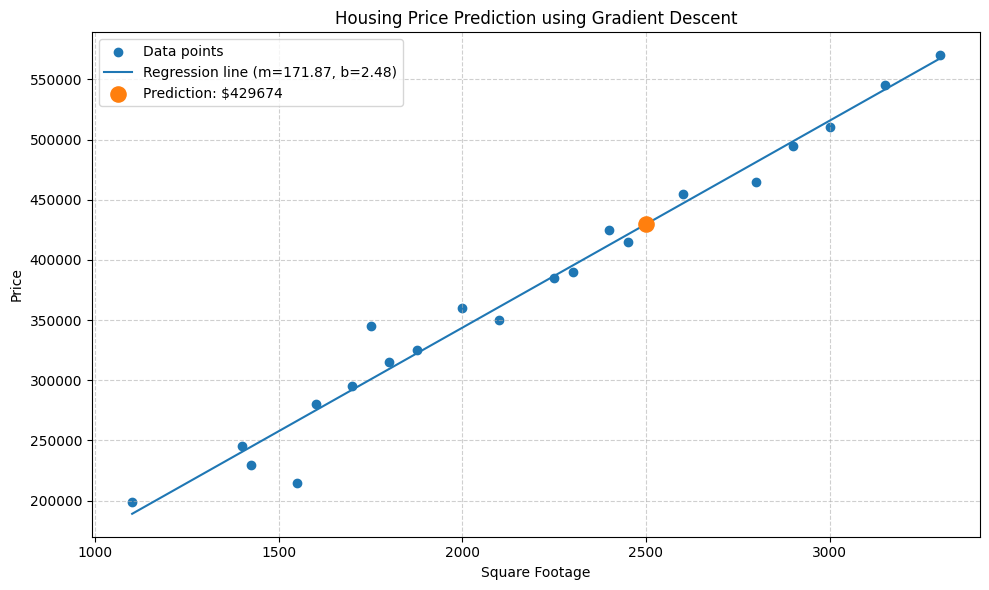

In [5]:
import csv
import numpy as np
import matplotlib.pyplot as plt


def save_sample_data(filename: str) -> None:
    data = [
        ["SquareFootage", "Price"],
        [1100, 199000], [1400, 245000], [1425, 230000], [1550, 215000],
        [1600, 280000], [1700, 295000], [1750, 345000], [1800, 315000],
        [1875, 325000], [2000, 360000], [2100, 350000], [2250, 385000],
        [2300, 390000], [2400, 425000], [2450, 415000], [2600, 455000],
        [2800, 465000], [2900, 495000], [3000, 510000], [3150, 545000],
        [3300, 570000],
    ]

    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerows(data)

    print("CSV file created successfully.\n")


def load_xy(filename: str):
    sqft = []
    price = []

    with open(filename, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            sqft.append(float(row["SquareFootage"]))
            price.append(float(row["Price"]))

    return np.array(sqft), np.array(price)


def compute_cost(x, y, m, b):
    pred = m * x + b
    return np.mean((y - pred) ** 2)


def train_linear_regression(x, y, lr=1e-7, epochs=100000, log_every=10000):
    m = 0.0
    b = 0.0
    n = len(x)
    history = []

    for epoch in range(epochs):
        y_hat = m * x + b
        error = y - y_hat

        dm = (-2.0 / n) * np.sum(x * error)
        db = (-2.0 / n) * np.sum(error)

        m -= lr * dm
        b -= lr * db

        if epoch % log_every == 0:
            history.append(compute_cost(x, y, m, b))

    return m, b, history


def predict_price(square_feet, m, b):
    return m * square_feet + b


def plot_fit(x, y, m, b, sqft_query, predicted_value):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="Data points")

    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = m * x_line + b
    plt.plot(x_line, y_line, label=f"Regression line (m={m:.2f}, b={b:.2f})")

    plt.scatter([sqft_query], [predicted_value], s=120, zorder=5,
                label=f"Prediction: ${predicted_value:.0f}")

    plt.title("Housing Price Prediction using Gradient Descent")
    plt.xlabel("Square Footage")
    plt.ylabel("Price")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def main():
    filename = "housing_data.csv"
    save_sample_data(filename)

    x, y = load_xy(filename)

    print("Training Gradient Descent model...")
    m, b, cost_history = train_linear_regression(x, y, lr=1e-7, epochs=100000)

    target_sqft = 2500
    prediction = predict_price(target_sqft, m, b)

    print("-" * 30)
    print(f"Slope (m): {m:.4f}")
    print(f"Intercept (b): {b:.4f}")
    print(f"Prediction for {target_sqft} sqft: ${prediction:.2f}")
    print("-" * 30)

    plot_fit(x, y, m, b, target_sqft, prediction)


if __name__ == "__main__":
    main()